In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score    
from sklearn.preprocessing import MinMaxScaler


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F




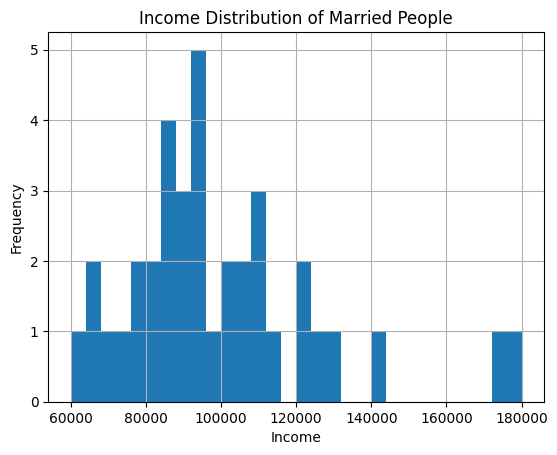

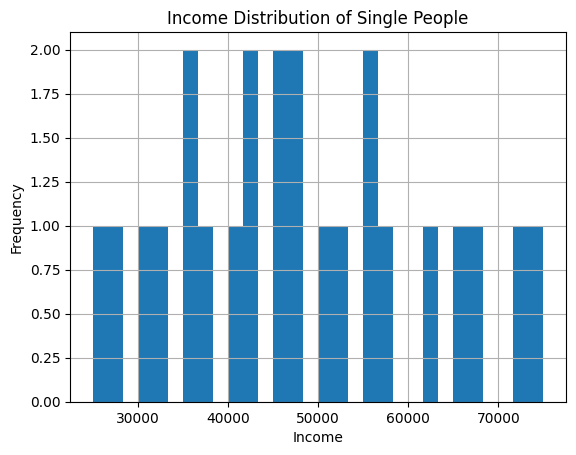

In [ ]:
df = pd.read_csv('loan.csv')
df.head()

df_married = df[df['marital_status'] == 'Married']
df_married['income'].hist(bins=30)
plt.title('Income Distribution of Married People')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

df_single = df[df['marital_status'] == 'Single']
df_single['income'].hist(bins=30)
plt.title('Income Distribution of Single People')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [ ]:
df.describe()

,age,income,credit_score
count,61.000000,61.000000,61.000000
mean,37.081967,78983.606557,709.836066
std,8.424755,33772.025802,72.674888
min,24.000000,25000.000000,560.000000
25%,30.000000,52000.000000,650.000000
50%,36.000000,78000.000000,720.000000
75%,43.000000,98000.000000,770.000000
max,55.000000,180000.000000,830.000000


In [ ]:
df.isna().sum()
#No missing values

age                0
gender             0
occupation         0
education_level    0
marital_status     0
income             0
credit_score       0
loan_status        0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=['occupation'])


In [ ]:
# Encode the gender column as numeric values so the model can use it.

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

df['marital_status'] = df['marital_status'].map({'Single': 0, 'Married': 1})

df['education_level'] = df['education_level'].map({'High School': 0, "Associate's": 1, "Bachelor's": 2, "Master's": 3 ,  "Doctoral": 4 })

df['loan_status'] = df['loan_status'].map({'Approved': 0, "Denied": 1})


df.head()

,age,gender,education_level,marital_status,income,credit_score,loan_status
0,32,0,2,1,85000,720,0
1,45,1,3,0,62000,680,0
2,28,0,0,0,25000,590,1
3,51,1,2,1,105000,780,0
4,36,0,2,1,75000,710,0


In [ ]:
#scaling the data

feature_columns = df.drop(columns=['loan_status'])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(feature_columns)
#print scaled data
X = pd.DataFrame(X_scaled, columns=feature_columns.columns)
print(X.head())

        age  gender  education_level  marital_status    income  credit_score
0  0.258065     0.0             0.50             1.0  0.387097      0.592593
1  0.677419     1.0             0.75             0.0  0.238710      0.444444
2  0.129032     0.0             0.00             0.0  0.000000      0.111111
3  0.870968     1.0             0.50             1.0  0.516129      0.814815
4  0.387097     0.0             0.50             1.0  0.322581      0.555556


In [ ]:
X = X_scaled
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [353]:
linear = LinearRegression()

linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f'Linear Regression Mean Squared Error: {mse_linear:.4f}')
print(f'Linear Regression R^2 Score: {r2_linear:.4f}')


Linear Regression Mean Squared Error: 0.0596
Linear Regression R^2 Score: 0.7202


In [354]:
#KNN

k = 11

knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN Accuracy: {accuracy_knn}')

#RMSE and R^2 for KNN
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f'KNN Mean Squared Error: {mse_knn:.4f}')
print(f'KNN R^2 Score: {r2_knn:.4f}')





KNN Accuracy: 0.9230769230769231
KNN Mean Squared Error: 0.0769
KNN R^2 Score: 0.6389


XGBoost Accuracy: 1.0000
XGBoost Mean Squared Error: 0.0000
XGBoost R^2 Score: 1.0000


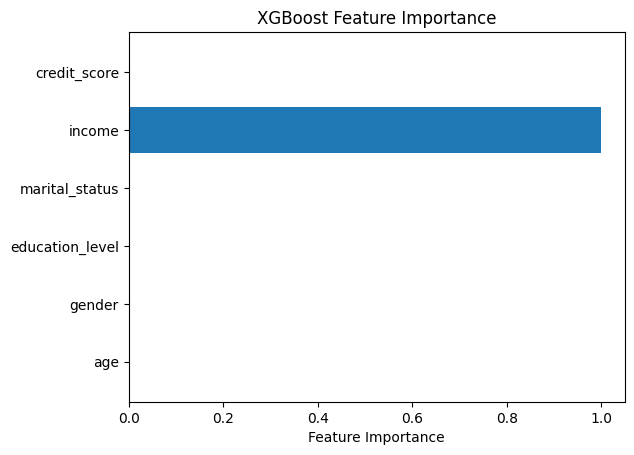

In [355]:
#XGboost

xgb = XGBClassifier(n_estimators=30, learning_rate=0.1, max_depth=2, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred)
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')

mse_xgb = mean_squared_error(y_test, y_pred)
r2_xgb = r2_score(y_test, y_pred)
print(f'XGBoost Mean Squared Error: {mse_xgb:.4f}')
print(f'XGBoost R^2 Score: {r2_xgb:.4f}')


feature_importance = xgb.feature_importances_
feature_names = df.drop(columns=['loan_status']).columns
plt.barh(feature_names, feature_importance)
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.show()



Random Forest Mean Squared Error: 0.0769
Random Forest R^2 Score: 0.6389
Random Forest Accuracy: 0.9231


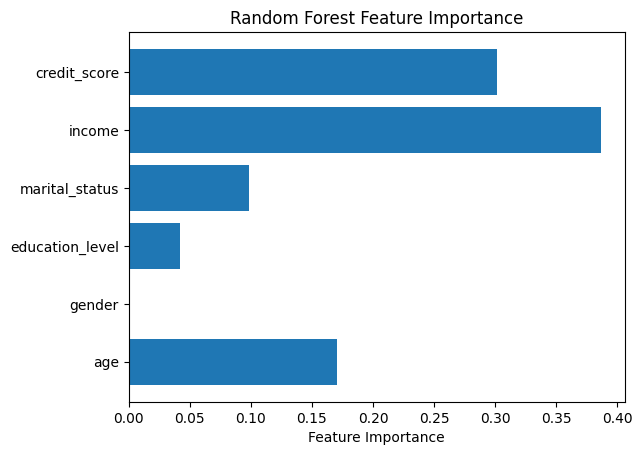

In [356]:
#Random Forest
rf = RandomForestClassifier(n_estimators=75, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Mean Squared Error: {mse_rf:.4f}')
print(f'Random Forest R^2 Score: {r2_rf:.4f}')
print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')


feature_importance_rf = rf.feature_importances_
feature_names_rf = df.drop(columns=['loan_status']).columns
plt.barh(feature_names_rf, feature_importance_rf)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


In [357]:
#neural network






X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2)

input_size = X_train.shape[1]
# Design of neural network
class nn1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 10) # input, # neurons in layer 1
        self.layer2 = nn.Linear(10, 1) 
    
    def forward(self, x):
        return F.sigmoid(self.layer2(F.relu(self.layer1(x))))

In [358]:
# Training of neural network
model = nn1()
loss = nn.BCELoss() ## For classification: Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [363]:
epochs = 500
for i in range(epochs):
    y_pred = model(X_train)
    loss_fn = loss(y_pred, y_train) # 1/n * (y - yp)^2
    optimizer.zero_grad()
    loss_fn.backward() # Compute derivatives
    optimizer.step() # Update weights

    if ((i+1) % 10 == 0):
        print('loss = ', loss_fn.item())
y_pred_nn = model(X_test)
y_pred_nn = (y_pred_nn > 0.5).float() 
accuracy_nn = accuracy_score(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
print(f'Neural Network Accuracy: {accuracy_nn:.4f}')
print(f'Neural Network Mean Squared Error: {mse_nn:.4f}')
print(f'Neural Network R^2 Score: {r2_nn:.4f}')

loss =  0.05195128917694092
loss =  0.05132066830992699
loss =  0.05069886893033981
loss =  0.050085533410310745
loss =  0.04948071017861366
loss =  0.04888414964079857
loss =  0.04829566553235054
loss =  0.047715213149785995
loss =  0.04714237153530121
loss =  0.04657762125134468
loss =  0.046020012348890305
loss =  0.045470230281353
loss =  0.044927407056093216
loss =  0.044391874223947525
loss =  0.04386360943317413
loss =  0.0433422289788723
loss =  0.042827755212783813
loss =  0.042320068925619125
loss =  0.04181919991970062
loss =  0.041324760764837265
loss =  0.04083681106567383
loss =  0.04035521671175957
loss =  0.03988004848361015
loss =  0.03941098600625992
loss =  0.03894811123609543
loss =  0.03849129006266594
loss =  0.03804035484790802
loss =  0.037595320492982864
loss =  0.037156086415052414
loss =  0.03672264516353607
loss =  0.03629499301314354
loss =  0.035872671753168106
loss =  0.03545606508851051
loss =  0.03504466637969017
loss =  0.034638483077287674
loss =  0.0